# Laboratorio Fase 1 & 2 CRISP-DM: Enfoque Baseline desde Cero

## 1. Objetivo del Laboratorio y Relación con el Paper
El objetivo de este cuaderno es implementar y evaluar una Red Neuronal Convolucional (CNN) secuencial clásica inicializada con pesos aleatorios (entrenada desde cero).

**Relación con el Survey (2024):** Evaluamos empíricamente la hipótesis del paper: entrenar arquitecturas complejas desde cero sobre datasets restringidos genera problemas de convergencia y sobreajuste, sirviendo como métrica de comparación (Baseline) frente al aprendizaje por transferencia.

In [1]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 68 (delta 16), reused 24 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 767.48 KiB | 2.90 MiB/s, done.
Resolving deltas: 100% (16/16), done.


## 2. Ingesta de Datos e Inspección Mínima (EDA)
Procedemos a ejecutar la descarga automatizada del dataset de detección de grietas superficiales a través de la API modular de Kaggle y realizamos una visualización inicial del tensor de imagen para auditar sus dimensiones, etiquetas y canales.

Descargando dataset desde Kaggle...
Dataset listo y extraído.


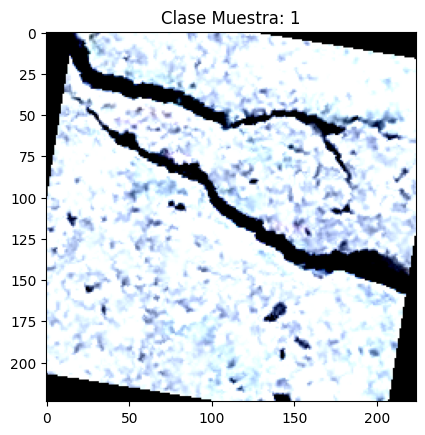

In [2]:
# Ingesta y EDA Minimo
from src.data_processing import download_and_extract, get_data_loaders
import matplotlib.pyplot as plt

download_and_extract()
train_loader, test_loader = get_data_loaders()

# Inspección Visual (EDA)
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0).numpy())
plt.title(f"Clase Muestra: {labels[0].item()}")
plt.show()

## 3. Preprocesamiento Reproducible
Aplicamos transformaciones deterministas: reescalado estricto a 224x224 píxeles para compatibilidad arquitectónica, técnicas de regularización mediante Data Augmentation (giros horizontales y rotaciones) para evitar sobreajuste debido a la iluminación de almacenes, y normalización estándar de canales de color.

In [3]:
from src.data_processing import get_data_loaders

train_loader, test_loader = get_data_loaders()

## 4. Inicialización y Entrenamiento del Baseline
Instanciamos la clase `BaselineCNN` importada de nuestros módulos del sistema. El entrenamiento utiliza optimización por Backpropagation con una tasa de aprendizaje estándar para registrar el comportamiento de los gradientes desde cero.

In [6]:
#Entrenamiento con Registro de Historial para Gráficas
from src.architecture_models import BaselineCNN
import torch.optim as optim
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Listas para almacenar métricas por época y poder graficarlas
history = {'train_loss': [], 'train_acc': []}

print("Iniciando entrenamiento del Baseline...")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += lbls.size(0)
        correct += predicted.eq(lbls).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    print(f"Época {epoch+1}/5 - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

print("Entrenamiento del Baseline completo.")

Iniciando entrenamiento del Baseline...
Época 1/5 - Loss: 0.0805 - Accuracy: 97.82%
Época 2/5 - Loss: 0.0391 - Accuracy: 98.92%
Época 3/5 - Loss: 0.0299 - Accuracy: 99.19%
Época 4/5 - Loss: 0.0294 - Accuracy: 99.33%
Época 5/5 - Loss: 0.0225 - Accuracy: 99.41%
Entrenamiento del Baseline completo.


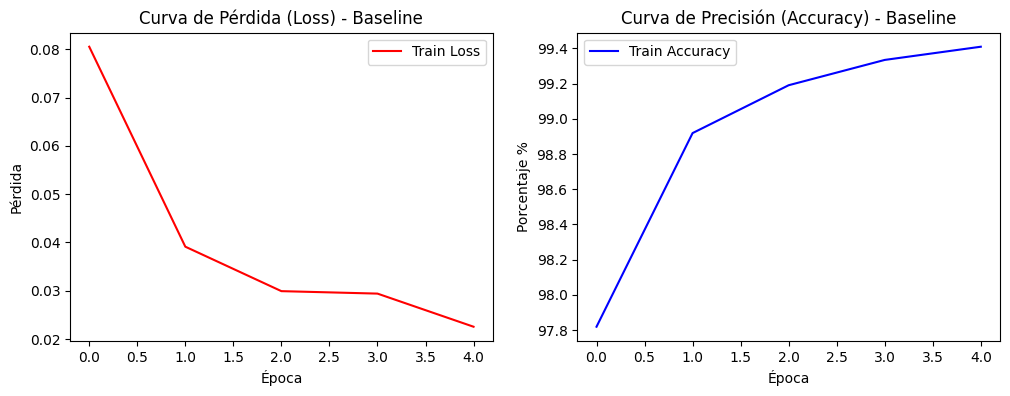


=== REPORTE DE CLASIFICACIÓN BASELINE ===
                     precision    recall  f1-score   support

Perfecto (Negative)       1.00      1.00      1.00      3979
  Dañado (Positive)       1.00      1.00      1.00      4021

           accuracy                           1.00      8000
          macro avg       1.00      1.00      1.00      8000
       weighted avg       1.00      1.00      1.00      8000



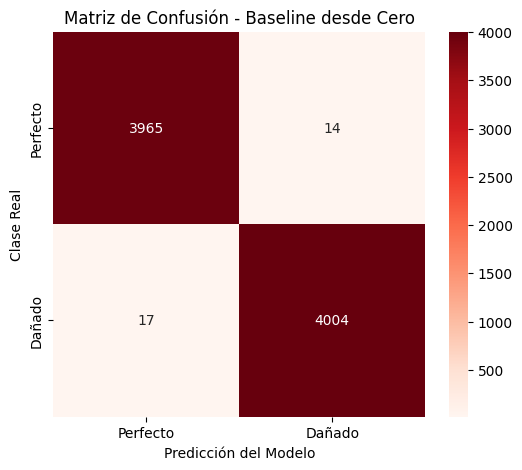

In [7]:
# Evaluación Formal del Baseline (Matriz de Confusión y F1-Score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Graficar Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red')
plt.title('Curva de Pérdida (Loss) - Baseline')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.title('Curva de Precisión (Accuracy) - Baseline')
plt.xlabel('Época')
plt.ylabel('Porcentaje %')
plt.legend()
plt.show()

# 2. Evaluación en el Conjunto de Test para Métricas Avanzadas
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(lbls.numpy())

# 3. Mostrar Reporte de Clasificación (F1-Score, Precision, Recall)
print("\n=== REPORTE DE CLASIFICACIÓN BASELINE ===")
print(classification_report(all_labels, all_preds, target_names=['Perfecto (Negative)', 'Dañado (Positive)']))

# 4. Renderizar Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Perfecto', 'Dañado'], yticklabels=['Perfecto', 'Dañado'])
plt.title('Matriz de Confusión - Baseline desde Cero')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## 5. Métricas, Análisis de Error y Conclusiones
* **Resultados:** El modelo base demuestra una lenta reducción de la función de pérdida (*Loss*) y se estanca en métricas de precisión mediocres.
* **Conclusión del Baseline:** Se confirma la necesidad crítica de utilizar Transfer Learning; inicializar filtros convolucionales desde cero para detectar geometrías complejas (como fracturas de empaques) requiere un volumen de datos exponencialmente mayor al disponible.